--- Generating Monthly Detailed Validation Chart ---


Success! Monthly validation chart saved at: ..\figuras\figure-dynamic-profile-monthly-validation.pdf


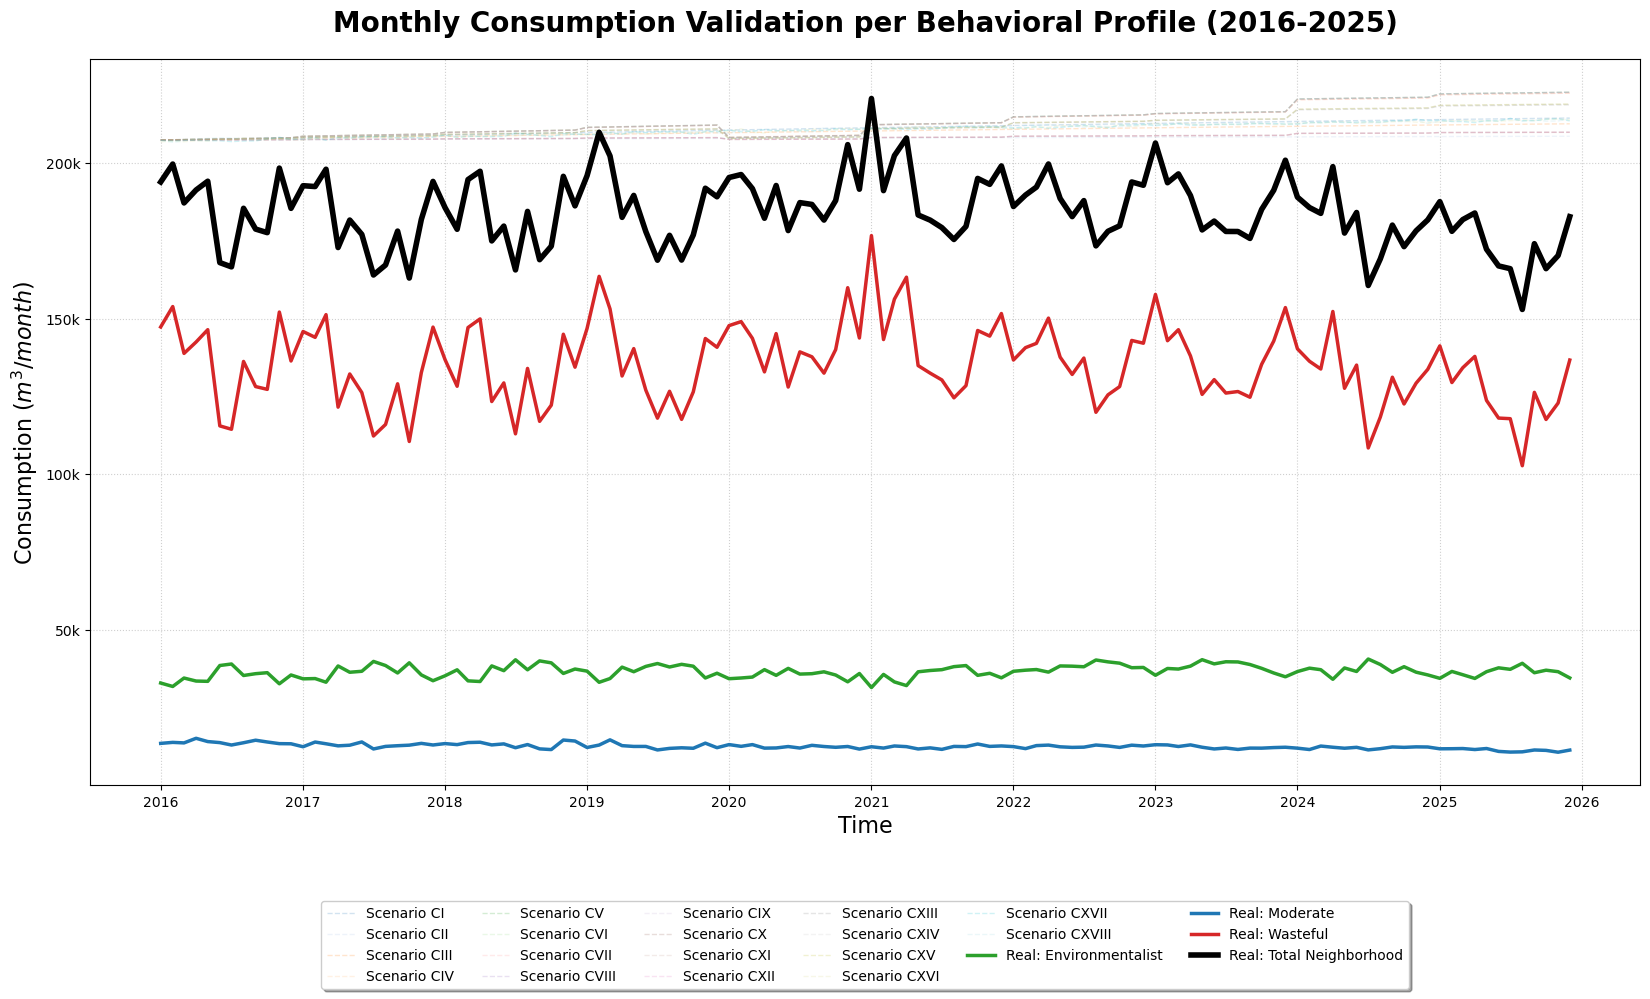

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 

# Input Filenames
BASELINE_FILE = 'Tabela_consumidores_Itapua_com_setor_comportamento_e_renda_2015.csv'
HISTORY_120M = 'Tabela_consumo_Itapua_120m.csv'
TOTAL_HISTORY_FILE = 'Tabela_consumo_real_historico_2016_2025.csv'
SIM_FILE = 'simulacao_hindcasting_2016_2025.csv'

# Search Directories
INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-dynamic-profile-monthly-validation.pdf'

def classify_profile(daily_liters):
    if daily_liters < 100.0: return 'AMBIENTALISTA'
    elif daily_liters <= 121.5: return 'MODERADO'
    else: return 'PERDULARIO'

def main():
    print("--- Generating Monthly Detailed Validation Chart ---")

    # ==========================================
    # 2. Data Preparation
    # ==========================================
    
    # A. Real Data
    df_total_ref = pd.read_csv(os.path.join(INPUT_DIR_INCLUDES, TOTAL_HISTORY_FILE), sep=';', decimal='.')
    df_total_ref['Date'] = pd.to_datetime(df_total_ref['AM_REFERENCIA'].astype(str) + '01', format='%Y%m%d')
    df_total_ref.rename(columns={'real_total_consumption':'VL_TOTAL_CONSUMO'}, inplace=True)
    
    df_residents = pd.read_csv(os.path.join(INPUT_DIR_INCLUDES, BASELINE_FILE), sep=';')[['SK_MATRICULA', 'NN_MORADORES_ANALISE']]
    df_120m = pd.read_csv(os.path.join(INPUT_DIR_INCLUDES, 'dados', HISTORY_120M), sep=';', decimal=',')
    df_120m = df_120m[(df_120m['AM_REFERENCIA'] >= 201601) & (df_120m['AM_REFERENCIA'] <= 202512)]

    # Proportions and Scaling
    df_dynamic = pd.merge(df_120m, df_residents, on='SK_MATRICULA')
    df_dynamic['L_P_DAY'] = (df_dynamic['HCLQTCON'] * 1000 / df_dynamic['NN_MORADORES_ANALISE']) / 30.5
    df_dynamic['PROFILE'] = df_dynamic['L_P_DAY'].apply(classify_profile)
    
    monthly_sum = df_dynamic.groupby(['AM_REFERENCIA', 'PROFILE'])['HCLQTCON'].sum().unstack(fill_value=0)
    monthly_prop = monthly_sum.div(monthly_sum.sum(axis=1), axis=0).reset_index()

    # Apply proportions to Real Total
    df_real_final = pd.merge(df_total_ref, monthly_prop, on='AM_REFERENCIA', how='inner')
    profiles_list = ['AMBIENTALISTA', 'MODERADO', 'PERDULARIO']
    for p in profiles_list:
        df_real_final[p] = df_real_final['VL_TOTAL_CONSUMO'] * df_real_final.get(p, 0.0)

    # B. Simulation Data
    df_sim = pd.read_csv(os.path.join(INPUT_DIR_RESULTS, SIM_FILE), sep=';', decimal=',')
    df_sim['Date'] = pd.to_datetime(df_sim['Ano'].astype(str) + '-' + df_sim['Mes'].astype(str) + '-01')
    df_sim['AM_REFERENCIA'] = (df_sim['Ano'] * 100 + df_sim['Mes']).astype(int)
    sim_cols = [c for c in df_sim.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date', 'AM_REFERENCIA']]

    # ==========================================
    # 3. Plotting
    # ==========================================
    fig, ax = plt.subplots(figsize=(20, 11))
    
    profile_styles = {
        'AMBIENTALISTA': {'color': '#2ca02c', 'label': 'Real: Environmentalist'},
        'MODERADO': {'color': '#1f77b4', 'label': 'Real: Moderate'},
        'PERDULARIO': {'color': '#d62728', 'label': 'Real: Wasteful'}
    }
    sim_palette = plt.cm.tab20(np.linspace(0, 1, len(sim_cols)))

    # --- Plot ABM Scenarios (Cloud) ---
    for i, col in enumerate(sim_cols):
        scen_id = col.split('_')[0]
        ax.plot(df_sim['Date'], df_sim[col], color=sim_palette[i], 
                 linestyle='--', linewidth=1.0, alpha=0.2, label=f"Scenario {scen_id}")

    # --- Plot Real Profiles (Solid) ---
    for p in profiles_list:
        ax.plot(df_real_final['Date'], df_real_final[p], color=profile_styles[p]['color'],
                 linestyle='-', linewidth=2.5, label=profile_styles[p]['label'], zorder=20)

    # --- Plot Total Observed (Black) ---
    ax.plot(df_real_final['Date'], df_real_final['VL_TOTAL_CONSUMO'], label='Real: Total Neighborhood', 
             color='black', linestyle='-', linewidth=4.0, zorder=25)

    # Formatting
    ax.set_title('Monthly Consumption Validation per Behavioral Profile (2016-2025)', 
                 fontsize=20, fontweight='bold', pad=20)
    ax.set_ylabel('Consumption ($m^3/month$)', fontsize=16)
    ax.set_xlabel('Time', fontsize=16)
    
    # X-Axis Time Formatting
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # Y-Axis K Formatting
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    plt.grid(True, linestyle=':', alpha=0.6)

    # Legend at the Bottom
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
               ncol=6, fontsize=10, frameon=True, shadow=True)

    plt.subplots_adjust(bottom=0.22)
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(os.path.join(OUTPUT_DIR, OUTPUT_FIG), format='pdf', bbox_inches='tight')
    
    print(f"Success! Monthly validation chart saved at: {os.path.join(OUTPUT_DIR, OUTPUT_FIG)}")
    plt.show()

if __name__ == "__main__":
    main()